<a href="https://colab.research.google.com/github/jfleon-dev/university-ai-labs/blob/main/Aprendizaje_competitivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizaje competitivo

Es un aprendizaje en el que varias neuronas "compiten" por responder a un patrón de entrada. Solo la neurona ganadora (la que más se parece al patrón de entrada) ajusta sus pesos. Las demás no cambian.
Por eso se le llama también “winner-takes-all” (el ganador se lo lleva todo).

### Regla de actualización

Solo la **neurona ganadora** $j^*$ ajusta sus pesos hacia el vector de entrada:

$$
w_{j^*}^{nuevo} = w_{j^*}^{viejo} + \eta (x - w_{j^*}^{viejo})
$$

Cada neurona termina acercando su vector de pesos a los patrones que gana con frecuencia.
Con el tiempo, las neuronas se especializan en diferentes regiones del espacio de datos.

### Ejemplo numérico

Supongamos:

* $x = [2,\,1]$
* Neurona 1: $w_1 = [1,\,0]$
* Neurona 2: $w_2 = [5,\,5]$
* $\eta = 0.2$

Distancias:

* $d_1 = \|[2,1]-[1,0]\| = \sqrt{2}$
* $d_2 = \|[2,1]-[5,5]\| = 5$

Gana la **neurona 1**.

Actualización:

$$
w_1^{nuevo} = [1,0] + 0.2([2,1]-[1,0]) = [1,0] + 0.2[1,1] = [1.2, 0.2]
$$

La neurona 1 “se acerca” al vector de entrada.


Datos cargados correctamente! Están en la variable X.


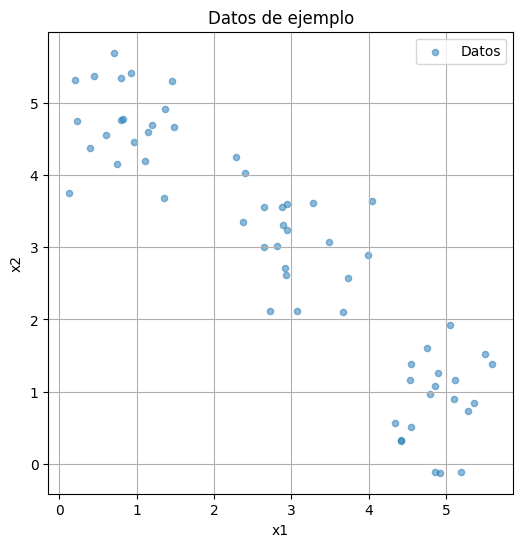

[[ 4.33799693  0.56498522]
 [ 4.53091685  1.16018551]
 [ 4.85085156  1.07588983]
 [ 5.50582554  1.51476193]
 [ 5.28511019  0.72953884]
 [ 4.54704063  0.51111154]
 [ 4.79368709  0.96917194]
 [ 4.41663579  0.31930748]
 [ 5.18342313 -0.11101102]
 [ 4.8937679   1.2554954 ]
 [ 4.40878664  0.33222752]
 [ 4.54362438  1.38881475]
 [ 4.92210119 -0.12175834]
 [ 4.74599053  1.60833808]
 [ 5.59022921  1.37802517]
 [ 4.85716472 -0.10696393]
 [ 5.10174664  0.89441334]
 [ 5.04607992  1.92538247]
 [ 5.11021012  1.16580029]
 [ 5.36305849  0.84605866]
 [ 0.6013862   4.55757617]
 [ 1.46017989  5.30273162]
 [ 0.70627212  5.69161719]
 [ 1.11059889  4.19586897]
 [ 1.36352738  4.91630859]
 [ 0.20271891  5.30929091]
 [ 0.79311009  4.76459444]
 [ 1.35393755  3.68450196]
 [ 0.23361987  4.7452879 ]
 [ 1.14949815  4.60093563]
 [ 0.40196966  4.36854615]
 [ 0.92962411  5.40501196]
 [ 0.12999873  3.75177259]
 [ 0.82157429  4.77078912]
 [ 0.45461173  5.36704566]
 [ 1.48277895  4.66149946]
 [ 0.79332916  5.34201752]
 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generamos datos de ejemplo
rng = np.random.default_rng(10)
grupo1 = rng.normal(loc=(5,1), scale=0.6, size=(20,2))
grupo2 = rng.normal(loc=(1,5), scale=0.6, size=(20,2))
grupo3 = rng.normal(loc=(3,3), scale=0.6, size=(20,2))

X = np.vstack([grupo1, grupo2, grupo3])
print("Datos cargados correctamente! Están en la variable X.")

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=20, alpha=0.5, label="Datos")
plt.title("Datos de ejemplo")
plt.xlabel("x1"); plt.ylabel("x2")
plt.legend(); plt.grid(True)
plt.show()

print(X)

Los pesos se pueden representar como una matriz. Por ejemplo, si tuvieramos dos neuronas

* Neurona 1: $w_1 = [1,\,0]$
* Neurona 2: $w_2 = [5,\,5]$

tendríamos

$$
W = \begin{bmatrix}1&0\\5&5\end{bmatrix}
$$

En python esto se puede representar mediante una lista de listas o un arreglo bidimensional en numpy.

In [ ]:
W = np.random.randn(2,2) + 3  # 2 neuronas con pesos aleatorios
eta = 0.2                  # tasa de aprendizaje

print("Pesos iniciales:\n", W)

Pesos iniciales:
 [[2.84209226 2.31748105]
 [1.32042003 2.36134454]]


In [ ]:
for fila in X:
    # Distancia de cada neurona a los datos de la fila
    dists = np.linalg.norm(W - fila, axis=1)
    ganador = np.argmin(dists)   # índice de la neurona ganadora

    # Actualización SOLO de la neurona ganadora
    W[ganador] = W[ganador] + eta * (fila - W[ganador])

print("Pesos finales:\n", W)

Pesos finales:
 [[ 2.03988018  1.95247434]
 [-2.06796145 -2.09504202]]


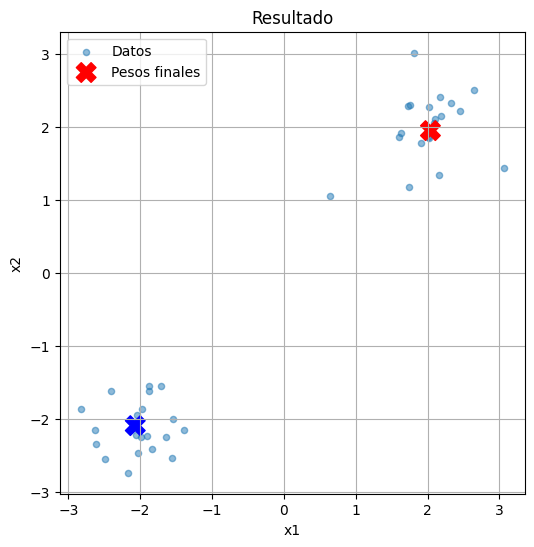

In [ ]:
plt.figure(figsize=(6,6))
# Datos
plt.scatter(X[:,0], X[:,1], s=20, alpha=0.5, label="Datos")

# Pesos finales
plt.scatter(W[:,0], W[:,1], marker="X", s=200, c=["red","blue"], label="Pesos finales")

plt.title("Resultado")
plt.xlabel("x1"); plt.ylabel("x2")
plt.legend(); plt.grid(True)
plt.show()

# Ejercicio 1

Contesta las siguientes preguntas en una celda de texto

1. Cambia la tasa de aprendizaje eta. ¿Qué pasa?
2. Añade un tercer grupo de datos pero mantén solo 2 neuronas. ¿Qué sucede?

# Ejercicio 2

Utiliza una red neuronal de tres neuronas (en lugar de dos) y resuelve el siguiente problema.

Supongamos que tenemos un grupo de estudiantes, y cada uno se describe por dos características:

* Horas de estudio individual por día (0 a 6).
* Horas de trabajo en grupo por día (0 a 6).

Queremos que 3 neuronas se especialicen en representar tipos de estudiante a partir de estos datos.

1. Corre la celda de generación de datos de ejemplo

2. Entrena una red neuronal usando aprendizaje competitivo sobre los datos e imprime los pesos finales

3. Al terminar, cada neurona tendrá pesos [x,y], que se interpretan como:
  * x: promedio de horas de estudio individual que representa esa neurona.
  * y: promedio de horas de trabajo en grupo.

Determina un nombre apropiado para cada uno de los tres grupos en base a tu interpretación de la información. ¿Cómo llamarías al grupo de estudiantes que estudia x horas de manera individual y y horas en grupo?

In [ ]:
#Corre esta celda para cargar los datos del ejercicio
import numpy as np

rng = np.random.default_rng(10)
grupo1 = rng.normal(loc=(5,1), scale=0.6, size=(20,2))
grupo2 = rng.normal(loc=(1,5), scale=0.6, size=(20,2))
grupo3 = rng.normal(loc=(3,3), scale=0.6, size=(20,2))

X = np.vstack([grupo1, grupo2, grupo3])
print("Datos cargados correctamente! Están en la variable X.")

Datos cargados correctamente! Están en la variable X.
